# ICU Early Warning Prediction System  
## Week 1 — Day 4  
## Advanced Machine Learning Models for Sepsis Prediction

This notebook focuses on improving ICU sepsis prediction performance using more advanced machine learning techniques.

In Day 3, a baseline Logistic Regression model was trained. The results were weak, which is expected because of the small dataset subset, class imbalance, and simplified patient-level feature aggregation.

In this notebook, we will improve the pipeline by using:
- balanced class weighting,
- an improved Logistic Regression model,
- a Random Forest classifier,
- model comparison,
- ROC curve analysis,
- confusion matrix analysis,
- and feature importance interpretation.

# 1. Import Required Libraries

This section imports the required libraries for data loading, preprocessing, model training, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

from sklearn.utils.class_weight import compute_class_weight

# 2. Create Output Folders

The figures and results generated in this notebook will be saved automatically inside the project structure.

In [2]:
os.makedirs("../figures/day4", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# 3. Load Processed ICU Dataset

The processed ICU dataset created during Day 2 is loaded.

This dataset contains patient-level features after preprocessing, missing value handling, and feature engineering.

In [5]:
import os

print(os.listdir("../data/processed"))

['day2_patient_level_features.csv']


In [6]:
df = pd.read_csv("../data/processed/day2_patient_level_features.csv")

df.head()

,Patient_ID,HR_mean,HR_max,HR_min,O2Sat_mean,O2Sat_min,Temp_mean,Temp_max,SBP_mean,SBP_min,MAP_mean,MAP_min,Resp_mean,Resp_max,Age_first,Gender_first,ICULOS_max,SepsisLabel_max
0,p000001,101.907407,117.0,76.0,91.453704,85.0,36.735185,37.44,127.870370,78.0,88.321111,44.00,24.555556,32.0,83.14,0,54,0
1,p000002,62.173913,94.0,54.0,97.043478,94.0,36.206087,37.00,129.043478,114.0,67.239130,50.50,14.630435,27.0,75.91,0,23,0
2,p000003,79.968750,93.0,68.0,95.375000,91.0,37.465000,38.61,139.760417,121.0,81.149167,62.67,25.302083,40.0,45.82,0,48,0
3,p000004,102.172414,113.0,89.0,98.189655,95.5,36.463103,37.00,113.017241,90.0,67.063103,34.00,18.758621,26.0,65.71,0,29,0
4,p000005,76.604167,88.0,61.0,97.677083,96.0,37.072292,37.33,135.072917,114.0,90.364583,73.00,15.447917,21.0,28.09,1,49,0


df = pd.read_csv("../data/processed/processed_icu_data.csv")

df.head()

# 4. Dataset Inspection

Before training advanced models, we inspect the dataset shape, columns, and target distribution.

This helps confirm that the dataset is correctly loaded and shows whether class imbalance exists.

In [7]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (100, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient_ID       100 non-null    object 
 1   HR_mean          100 non-null    float64
 2   HR_max           100 non-null    float64
 3   HR_min           100 non-null    float64
 4   O2Sat_mean       100 non-null    float64
 5   O2Sat_min        100 non-null    float64
 6   Temp_mean        100 non-null    float64
 7   Temp_max         100 non-null    float64
 8   SBP_mean         100 non-null    float64
 9   SBP_min          100 non-null    float64
 10  MAP_mean         100 non-null    float64
 11  MAP_min          100 non-null    float64
 12  Resp_mean        100 non-null    float64
 13  Resp_max         100 non-null    float64
 14  Age_first        100 non-null    float64
 15  Gender_first     100 non-null    int64  
 16  ICULOS_max       100 non-null    int64

In [10]:
df["SepsisLabel_max"].value_counts()

SepsisLabel_max
0    86
1    14
Name: count, dtype: int64

In [12]:
df["SepsisLabel_max"].value_counts()

SepsisLabel_max
0    86
1    14
Name: count, dtype: int64

# 5. Understanding Class Imbalance

In ICU sepsis prediction, class imbalance is very common.

Usually, the number of non-septic patients is much higher than the number of septic patients. This can cause the model to become biased toward predicting the majority class.

Because missing a septic patient can be clinically dangerous, recall is especially important in this project.

To reduce the effect of class imbalance, this notebook uses:
- stratified train/test splitting,
- class weighting,
- and performance metrics beyond accuracy.

# 6. Define Features and Target Variable

The dataset is separated into:

- `X`: input clinical features
- `y`: target variable, which indicates whether the patient developed sepsis

In [14]:
X = df.drop(columns=["Patient_ID", "SepsisLabel_max"])
y = df["SepsisLabel_max"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (100, 16)
Target shape: (100,)


# 7. Train/Test Split

The dataset is split into training and testing sets.

Stratification is used to preserve the same sepsis/non-sepsis distribution in both sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (80, 16)
Testing set: (20, 16)


# 8. Compute Class Weights

Class weights help the model pay more attention to the minority class.

This is important because septic patients are usually underrepresented in ICU datasets.

In [16]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

class_weight_dict

{0: np.float64(0.5797101449275363), 1: np.float64(3.6363636363636362)}

# 9. Feature Scaling

Feature scaling is applied for Logistic Regression because this model is sensitive to differences in feature ranges.

Random Forest does not require scaling because it is a tree-based model.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Train Improved Logistic Regression Model

The Logistic Regression model is retrained using balanced class weighting.

This gives a stronger baseline model for comparison with Random Forest.

In [19]:
lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# 11. Train Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple decision trees.

It is useful in medical prediction tasks because it can:
- capture non-linear relationships,
- handle complex feature interactions,
- reduce overfitting compared to a single decision tree,
- and provide feature importance scores.

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 12. Define Model Evaluation Function

A reusable evaluation function is created to calculate the main performance metrics.

The metrics used are:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For sepsis prediction, recall is especially important because false negatives may represent missed septic patients.

In [21]:
def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }
    
    return metrics

# 13. Evaluate Both Models

The improved Logistic Regression model and Random Forest model are evaluated on the same test set.

In [22]:
lr_metrics = evaluate_model(y_test, lr_preds, lr_probs)
rf_metrics = evaluate_model(y_test, rf_preds, rf_probs)

print("Improved Logistic Regression Metrics:")
print(lr_metrics)

print("\nRandom Forest Metrics:")
print(rf_metrics)

Improved Logistic Regression Metrics:
{'Accuracy': 0.5, 'Precision': 0.1111111111111111, 'Recall': 0.3333333333333333, 'F1-Score': 0.16666666666666666, 'ROC-AUC': 0.47058823529411764}

Random Forest Metrics:
{'Accuracy': 0.85, 'Precision': 0.0, 'Recall': 0.0, 'F1-Score': 0.0, 'ROC-AUC': 0.7254901960784313}


# 14. Save Model Comparison Results

The results of both models are saved into a CSV file for documentation and future reporting.

In [23]:
comparison_df = pd.DataFrame(
    [lr_metrics, rf_metrics],
    index=["Improved Logistic Regression", "Random Forest"]
)

comparison_df.to_csv("../results/model_comparison.csv")

comparison_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Improved Logistic Regression,0.50,0.111111,0.333333,0.166667,0.470588
Random Forest,0.85,0.000000,0.000000,0.000000,0.725490


comparison_df = pd.DataFrame(
    [lr_metrics, rf_metrics],
    index=["Improved Logistic Regression", "Random Forest"]
)

comparison_df.to_csv("../results/model_comparison.csv")

comparison_df

# 15. Random Forest Classification Report

The classification report provides precision, recall, and F1-score for each class.

This helps us understand how the model performs separately on non-sepsis and sepsis patients.

In [26]:
print(classification_report(y_test, rf_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       0.00      0.00      0.00         3

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20



# 16. Random Forest Confusion Matrix

The confusion matrix shows:

- true negatives,
- false positives,
- false negatives,
- and true positives.

In sepsis prediction, false negatives are especially important because they represent septic patients that the model failed to detect.

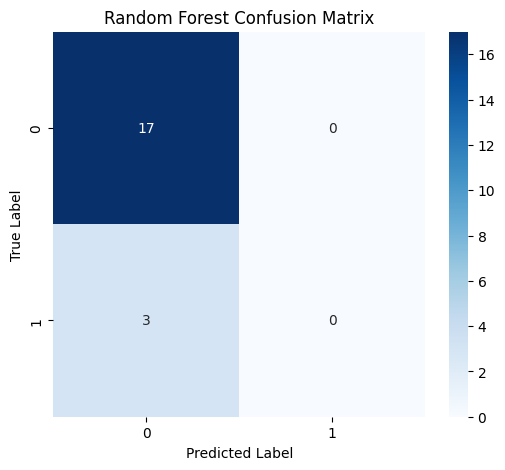

In [27]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("../figures/day4/random_forest_confusion_matrix.png", bbox_inches="tight")
plt.show()

# 17. Random Forest ROC Curve

The ROC curve shows how well the model separates septic and non-septic patients across different decision thresholds.

The ROC-AUC score summarizes this performance.

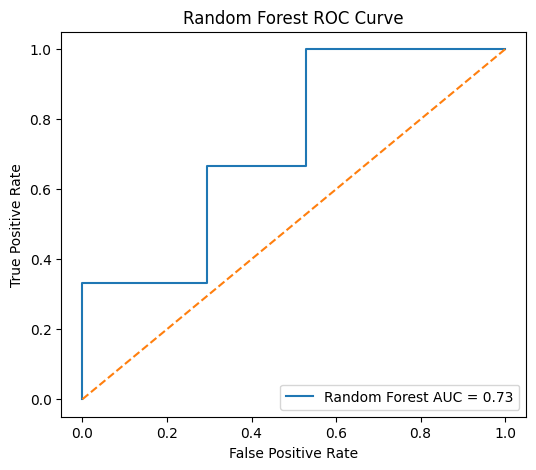

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Random Forest AUC = {rf_metrics['ROC-AUC']:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.savefig("../figures/day4/random_forest_roc_curve.png", bbox_inches="tight")
plt.show()

# 18. Random Forest Feature Importance

Random Forest provides feature importance values.

These values help identify which clinical variables contributed most to the model's predictions.

In [29]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.to_csv("../results/rf_feature_importance.csv", index=False)

importance_df.head(10)

,Feature,Importance
15,ICULOS_max,0.147810
2,HR_min,0.112628
5,Temp_mean,0.077629
0,HR_mean,0.074893
7,SBP_mean,0.072544
4,O2Sat_min,0.070293
3,O2Sat_mean,0.063717
11,Resp_mean,0.056398
13,Age_first,0.053201
1,HR_max,0.052939


# 19. Visualize Top Feature Importances

The top 10 most important features are visualized.

This allows us to interpret whether the model is relying on clinically meaningful variables.

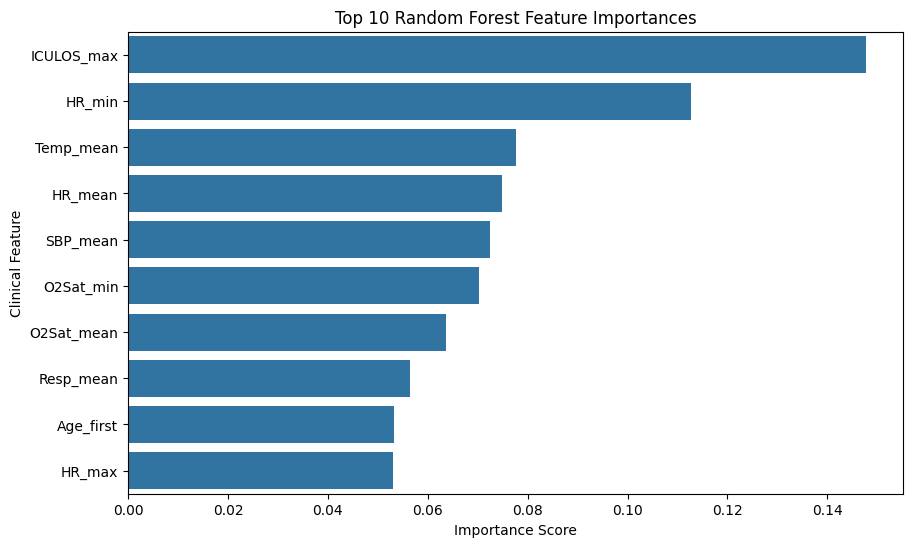

In [30]:
top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Clinical Feature")

plt.savefig("../figures/day4/feature_importance_rf.png", bbox_inches="tight")
plt.show()

# 20. Model Comparison Visualization

The performance of Logistic Regression and Random Forest is compared visually across all evaluation metrics.

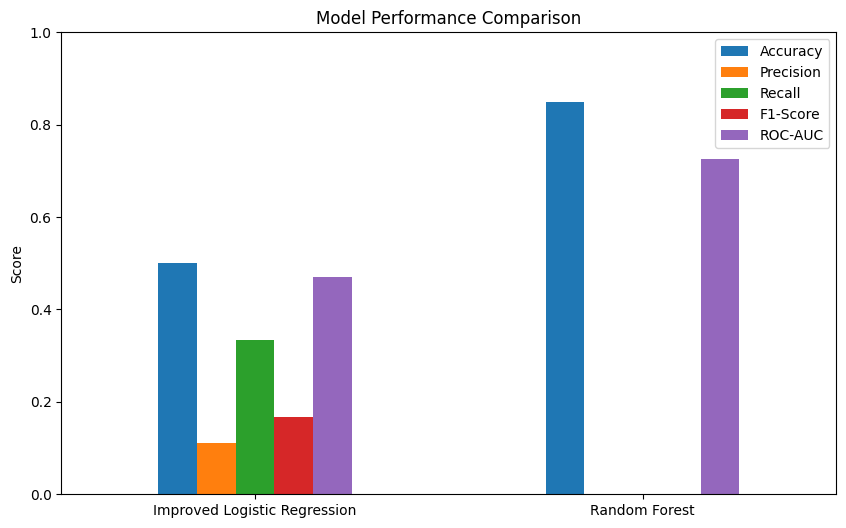

In [31]:
comparison_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.savefig("../figures/day4/model_comparison.png", bbox_inches="tight")
plt.show()

# 21. Save Random Forest Metrics Separately

The Random Forest results are saved separately for documentation.

In [32]:
rf_metrics_df = pd.DataFrame([rf_metrics])

rf_metrics_df.to_csv("../results/random_forest_metrics.csv", index=False)

rf_metrics_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.85,0.0,0.0,0.0,0.72549


# 22. Clinical Interpretation

The Random Forest model was introduced to improve the prediction of sepsis by capturing non-linear relationships between ICU variables.

Compared to Logistic Regression, Random Forest can better model complex interactions between clinical features such as heart rate, respiratory rate, blood pressure, temperature, laboratory measurements, and ICU length of stay.

The feature importance analysis helps identify which variables contributed most to the prediction of sepsis risk.

If clinically meaningful variables such as heart rate, respiratory rate, temperature, blood pressure, and ICU length of stay appear among the top features, this supports the medical relevance of the model.

However, performance may still remain limited because of:
- small dataset size,
- class imbalance,
- patient-level aggregation,
- and lack of temporal sequence modeling.

This result is expected at this early stage of the project.

# 23. Limitations

Although Random Forest is more powerful than Logistic Regression, this experiment still has important limitations.

The current model uses aggregated patient-level features, which means that temporal ICU patterns are simplified.

In real ICU early warning systems, the timing and progression of vital signs are extremely important.

Another limitation is the small dataset subset, which makes model performance unstable and sensitive to the train/test split.

Class imbalance also remains a major challenge because septic cases are much less frequent than non-septic cases.

# 24. Future Work

Future improvements may include:

- using XGBoost or LightGBM,
- applying SMOTE oversampling,
- performing hyperparameter optimization,
- using larger ICU datasets,
- adding more advanced temporal feature engineering,
- training LSTM or Transformer-based time-series models,
- and building a real-time ICU early warning dashboard.

These future steps will help move the project closer to a clinically realistic early warning prediction system.

# 25. Day 4 Summary

In this notebook, advanced machine learning methods were applied to improve sepsis prediction.

The main completed tasks were:

- loaded the processed ICU dataset,
- inspected target class imbalance,
- applied stratified train/test splitting,
- trained an improved Logistic Regression model,
- trained a Random Forest classifier,
- evaluated both models,
- generated confusion matrix and ROC curve visualizations,
- analyzed Random Forest feature importance,
- saved results and figures automatically.

This notebook represents an important step from a basic baseline model toward a stronger clinical machine learning pipeline.